# Photovoltaic Figure of Merit Code Main Tutorial Notebook

At current this is only tested in inorganic semiconductor (non-perovskite) photovoltaic materials

In [1]:
#import the required modules

import solphin.db_fom as db_fom
import solphin.pv_fom as pv_fom
import solphin.db_plotting as db_plotting
import solphin.final_results as final_results
import solphin.vasp_inputs as vasp_inputs
import solphin.optics as optics
import solphin.spectral as spectral
import numpy as np # version - 1.26.4

## Using PV-FOM to generate VASP calculation files

### Geometry Optimisation

The initial step of any DFT structural property study is a geometry optimisation to find the lowest energy position of the atoms in your system. For this you need:

- A starting structure, this can be obtained from the ICSD, materials project or experimental studies. The current code accepts VASP POSCAR/CONTCAR, .cif, .xyz or .json.
- Appropiate values for the ENCUT and KSPACING for your system. Convergence testing is the commonly used method of determining the appropiate values.
- The desired functional, it is recommended to use hybrid-DFT (HSE06 or PBE0) to achieve publishable results.

In [2]:
# Set the structure filename and calculation settings

filename = 'cdte/relaxed_primitive_POSCAR'
outdirectory = 'relax' # The folder you want to run the calculation in
functional = 'HSE06'            # The DFT functional
encut = 450                     
kspacing = 0.2

In [3]:

# Load the structure
structure = vasp_inputs.read_structure_pmg(filename)

# Generate the calculations
vasp_inputs.write_vasp_calculation(structure=structure, recipe=functional, out_dir=outdirectory, patches=['relax_cell', 'tight_relax'], user_incar_settings={"KSPACING": kspacing, "ENCUT": encut})

/home/puc369/miniconda3/envs/toolbox/lib/python3.12/site-packages/pymatgen/io/vasp/inputs.py:2507: UnknownPotcarWarning: POTCAR data with symbol Te is not known to pymatgen. Your POTCAR may be corrupted or pymatgen's POTCAR database is incomplete.
  return cls(file.read(), symbol=symbol or None)  # type:ignore[arg-type]


### Density of States 

This is required as a precursor to the optical absorption calculation that we need for much of the analysis. This time the structure we feed in is the CONTCAR from the Relaxation.

In [4]:
filename = 'relax/CONTCAR'
outdirectory = 'dos'

# Load the structure
structure = vasp_inputs.read_structure_pmg(filename)

# Generate the calculations
vasp_inputs.write_vasp_calculation(structure=structure, recipe=functional, out_dir=outdirectory, patches=["dos"], user_incar_settings={"KSPACING": kspacing, "ENCUT": encut, "ISPIN": 1, "ISMEAR": -5, "SIGMA": 0.02})

#### Analysing the Density of States


In [2]:
from sumo.cli.dosplot import dosplot

dosplot(filename='dos/vasprun.xml', xmin=-3, xmax=3, gaussian=0.05)

### Optical Calculations

This can be ran in the same folder as the density of states calculation - warning it will overwrite the previous DOS INCAR in order to do so.

In [3]:
filename = 'dos/POSCAR'
outdirectory = 'dos'

# Load the structure
structure = vasp_inputs.read_structure_pmg(filename)

# Generate the calculations
vasp_inputs.write_vasp_calculation(structure=structure, recipe=functional, out_dir=outdirectory, patches=["optics"], user_incar_settings={"KSPACING": kspacing, "ENCUT": encut, "ISPIN": 1, "ISMEAR": -5, "SIGMA": 0.02})

NameError: name 'functional' is not defined

### Analysing the Optical Calculations

The initial step is using sumo to generate the required files, and plot the absorption onset.

In [4]:
# Generating the absorption.dat file and absorption onset plot, this will be saved as a PDF in the DOS folder

from sumo.cli.optplot import optplot

optplot(filenames='dos/vasprun.xml', directory='dos', xmax=5)

Followed by generating the SLME and Blank et.al metric.

In [5]:
# Generates a n_real.dat for use in SLME and Blank et al

filename = 'dos/vasprun.xml'
optics.generate_n_real(filename)

In [2]:
# Use adapted blank metric code to generate flat_eta_out & lamb_eta_out
spectrum = db_fom.load_spectrum(spectrum_type="AM1.5")
photon_spectrum = db_fom.convert_spectrum(spectrum) #Fix spectrum read error and work out which spectrum is required. 

folder = 'dos'


In [3]:
optics.blank_calculate(photon_spectrum, folder)

TypeError: read_table() got an unexpected keyword argument 'delim_whitespace'

In [4]:
dir = 0.14# Direct Bandgap of your material from the band_std
indir= 0.15 # Indirect Bandgap of your material from the band_std (if none given use the direct bandgap twice)

#Get energy and absorption form absorption.dat. Get from sumo-optplot
abs_file = 'absorption_Imm2_Cu2GeSe3.dat'

In [5]:
spectral_average, spectral_dispersion = spectral.generate_spectral_parameters(abs_file, spectrum, E_gap=dir)

print(spectral_average, spectral_dispersion)

235736.2204403675 0.28221443666427715


# SLME

[2.24000e-02 4.49000e-02 6.73000e-02 ... 6.72290e+01 6.72514e+01
 6.72738e+01]
6.404149967680691
Running full Blank SLME plot


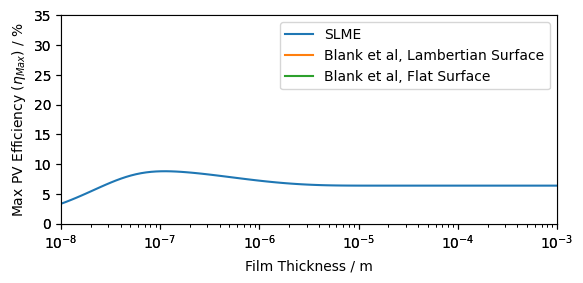

In [10]:

energy, alpha_cm = spectral.load_absorption(abs_file)

print(energy)

#Test to see if this works for a specific thickness
data = slme.slme(energy, alpha_cm, dir, indir, thickness=1e-05, absorbance_in_inverse_centimeters=True)

print(data)

# Now run for multiple thicknesses 

thickness = np.logspace(-8, -3, 100, endpoint=True)
effSlm = []

for i in thickness:
    eff = data = slme.slme(energy, alpha_cm, dir, indir, thickness=i, absorbance_in_inverse_centimeters=True)
    effSlm.append(eff)

# Plot the SLME results

ax = plt.axes()
plt.plot(thickness, effSlm)
plt.xscale('log')
plt.margins(x=0)
plt.ylim([0, 35])
plt.xlabel('Film Thickness / m', labelpad=5)
plt.ylabel('Max PV Efficiency $(\eta_{Max})$ / %')
ax.set_aspect(0.06)
plt.savefig('slme.pdf', format='pdf')

# You should have ran the Blank_Metric module from github - Chris Savory and have flat_eta_out and lamb_eta_out files

print('Running full Blank SLME plot')

lamb = np.loadtxt('lamb_eta_out', skiprows=0)
thickness_lamb = lamb[:,0]
eff_lamb = [x*100 for x in lamb[:,1]]

flat = np.loadtxt('flat_eta_out', skiprows=0)
thickness_flat = flat[:,0]
eff_flat = [x*100 for x in flat [:,1]]

ax = plt.axes()
plt.plot(thickness, effSlm, label = 'SLME')
plt.plot(thickness_lamb, eff_lamb, label = 'Blank et al, Lambertian Surface')
plt.plot(thickness_flat, eff_flat, label = 'Blank et al, Flat Surface')
plt.xscale('log')
plt.margins(x=0)
plt.ylim([0, 35])
ax.set_aspect(0.06)
plt.legend()
plt.savefig('pveff.pdf', format='pdf')

The Tauc Plots can then be generated

### Obtaining the Detailed Balance from Bandgap

Using the optical gaps taken from the Tauc Plots, the Detailed balance can be calculated. 

In [6]:
# Define the operating temperature of the cell, and bandgap from the Tauc plot

Tcell = 300
Egap = 1.45   # Using CdTe value

In [7]:
# Convert the spectrum

spectrum = db_fom.load_spectrum(spectrum_type="AM1.5")
photon_spectrum = db_fom.convert_spectrum(spectrum)


/home/puc369/Documents/Linux_working/Figure_of_merit/Solphin/solphin/db_plotting.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot([Egap], [p_above_1_1], 'ro', color='#FF6666')


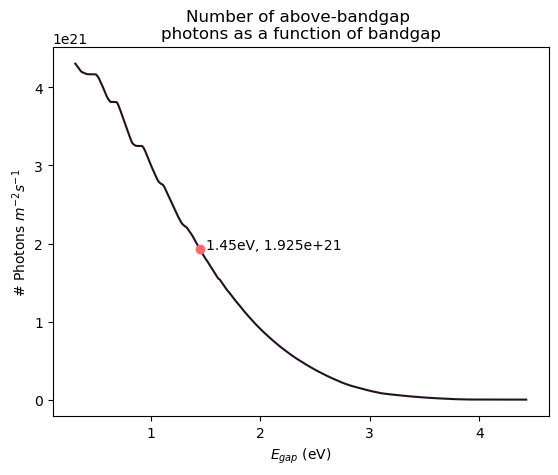

In [8]:
# Plot the phonons above bandgap

db_plotting.photons_above_bandgap_plot(photon_spectrum, Egap)

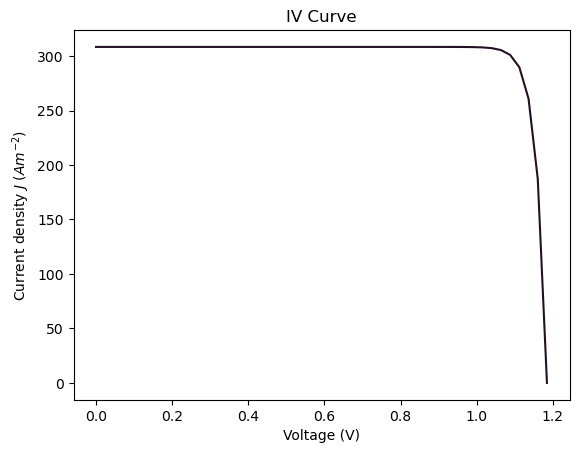

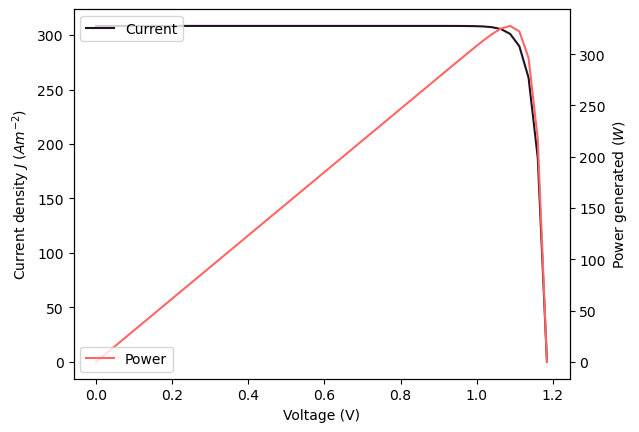

In [9]:
# IV Curve

db_plotting.iv_curve_plot(Egap, photon_spectrum, Tcell)
db_plotting.iv_curve_plot_2(Egap, photon_spectrum, Tcell)

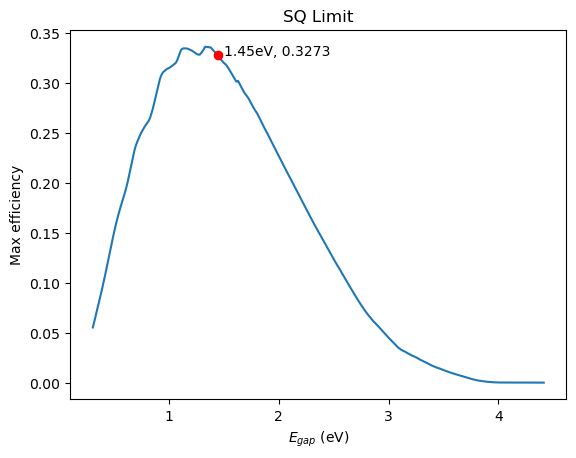

In [10]:
# The SQ limit plot

db_plotting.sq_limit_plot(photon_spectrum, Egap, Tcell)